# 03 · Data Cleaning
**Project:** LendingClub loan default prediction  
**Input:** `data/interim/accepted_2007_to_201804.parquet`  
**Output:** `data/interim/lendingclub_clean.parquet`

---

## Contents
1. Setup and data loading
2. Remove invalid rows
3. Define the target
4. Scope and column selection
5. Missingness assessment
6. Data types and categorical fields
7. Value validity
8. Missing-value handling
9. Sample window
10. Save and summary

---

## Cleaning plan and status

| # | Step | Status |
|---|------|--------|
| 1 | Remove invalid rows and check for duplicates | Done |
| 2 | Define the binary target and remove loans without a known outcome | Done |
| 3 | Apply the column selection (candidate features, target, `issue_d`) | Done |
| 4 | Fix data types (`term`, `emp_length`, categorical columns, `zip_code`) | Done |
| 5 | Assess missingness in numeric candidates | Done (decisions in section 8) |
| 6 | Handle joint applications | Done: scope restricted to individual applications |
| 7 | Check value validity (`dti`, `annual_inc`, `revol_util`, FICO, other columns) | Done |
| 8 | Clean categorical fields (rare categories, `addr_state`, `zip_code`) | Done |
| 9 | Save the cleaned dataset and log row/column counts | Done |
| 10 | Fix the sample window (right-censored recent loans) | Done: loans issued up to 2014 (section 3.4) |

## Scope of this notebook
I only do **stateless** cleaning here: rules that learn nothing from the data (invalid rows, target definition, column selection, type conversion, fixed value mappings, missing-value indicators).

Anything that is **fitted on the data** (imputers, encoders, scalers, percentile-based capping thresholds, grouping based on the default rate) must happen *after* the time-based split on `issue_d`, using the training data only, to avoid leakage.

## 1. Setup and data loading

In [103]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

DATA_PATH = Path("..") / "data" / "interim" / "accepted_2007_to_201804.parquet"
OUTPUT_PATH = Path("..") / "data" / "interim" / "lendingclub_clean.parquet"
TARGET = "default"
SPLIT_KEY = "issue_d"

# Row/column counts after each cleaning step
step_log = []


def log_step(step: str, frame: pd.DataFrame) -> None:
    step_log.append({"step": step, "rows": len(frame), "columns": frame.shape[1]})

In [104]:
df = pd.read_parquet(DATA_PATH)
log_step("Raw data loaded", df)

print(f"Raw data: {df.shape[0]:,} rows x {df.shape[1]} columns")

Raw data: 2,260,701 rows x 151 columns


## 2. Remove invalid rows

### 2.1 Rows with missing core categorical values
Fields such as `term`, `grade`, `purpose` and `loan_status` should be populated for every real loan. Rows where any of them is missing are inspected first.

In [105]:
low_null_cols = [
    "term",
    "grade",
    "sub_grade",
    "home_ownership",
    "verification_status",
    "loan_status",
    "pymnt_plan",
    "purpose",
    "initial_list_status",
    "application_type",
    "hardship_flag",
    "disbursement_method",
    "debt_settlement_flag",
    "addr_state",
    "zip_code",
]

invalid_mask = df[low_null_cols].isna().any(axis=1)
invalid_rows = df.loc[invalid_mask]

non_numeric_ids = pd.to_numeric(invalid_rows["id"], errors="coerce").isna().sum()

print(f"Rows with a missing core categorical value: {invalid_mask.sum():,} ({invalid_mask.mean():.4%} of all rows)")
print(f"Share of null cells in those rows:          {invalid_rows.isna().mean().mean():.2%}")
print(f"Rows with a non-numeric loan id:            {non_numeric_ids} of {len(invalid_rows)}")

invalid_rows[["id", "loan_status"]].head(6)

Rows with a missing core categorical value: 34 (0.0015% of all rows)
Share of null cells in those rows:          97.27%
Rows with a non-numeric loan id:            33 of 34


,id,loan_status
421095,Total amount funded in policy code 1: 6417608175,None
421096,Total amount funded in policy code 2: 1944088810,None
528961,Total amount funded in policy code 1: 1741781700,None
528962,Total amount funded in policy code 2: 564202131,None
651664,Total amount funded in policy code 1: 1791201400,None
651665,Total amount funded in policy code 2: 651669342,None


These rows are not loans. They are summary lines from the original export (their `id` reads "Total amount funded in policy code ...") and are about 97% null, so they are removed.

In [106]:
df = df.drop(index=invalid_rows.index)
log_step("Invalid summary rows removed", df)

print(f"Shape after removal: {df.shape}")

Shape after removal: (2260667, 151)


### 2.2 Duplicate check
Every loan has a unique `id`, so unique ids also rule out fully duplicated rows. This is much cheaper than comparing all 151 columns of 2.2 million rows.

In [107]:
n_duplicate_ids = df["id"].duplicated().sum()
print(f"Duplicated loan ids: {n_duplicate_ids:,}")

df = df.drop_duplicates(subset="id")  # no-op when there are no duplicates
log_step("Duplicates checked", df)

Duplicated loan ids: 0


## 3. Define the target

### 3.1 Loan status mapping
Only loans with a **final, known outcome** are used for modelling. Loans that are still in their repayment lifecycle have no outcome yet, so they are excluded rather than guessed.

| `loan_status` | Meaning | Treatment | Reason |
|---|---|---|---|
| Fully Paid | Borrower repaid the loan in full | `default = 0` | Known good outcome |
| Does not meet the credit policy. Status:Fully Paid | Older loan outside the current credit policy, fully repaid | `default = 0` | Known good outcome |
| Charged Off | Lender considers the loan unlikely to be recovered | `default = 1` | Known bad outcome |
| Does not meet the credit policy. Status:Charged Off | Older loan outside the current credit policy, charged off | `default = 1` | Known bad outcome |
| Default | Loan has formally defaulted | `default = 1` | Known bad outcome |
| Current | Being paid on schedule | Excluded | Outcome not known yet |
| In Grace Period | Overdue, but within the grace period | Excluded | Still in the repayment lifecycle |
| Late (16-30 days) | 16-30 days overdue | Excluded | Not necessarily a default |
| Late (31-120 days) | 31-120 days overdue | Excluded | Serious delinquency, but not a final outcome |

In [108]:
STATUS_TO_TARGET = {
    "Fully Paid": 0,
    "Does not meet the credit policy. Status:Fully Paid": 0,
    "Charged Off": 1,
    "Does not meet the credit policy. Status:Charged Off": 1,
    "Default": 1,
}

EXCLUDED_STATUSES = [
    "Current",
    "In Grace Period",
    "Late (16-30 days)",
    "Late (31-120 days)",
]

# Every status in the data must be handled explicitly
unhandled = set(df["loan_status"].unique()) - set(STATUS_TO_TARGET) - set(EXCLUDED_STATUSES)
assert not unhandled, f"Unmapped loan_status values: {unhandled}"

status_summary = df["loan_status"].value_counts().rename("loans").to_frame()
status_summary["share_%"] = status_summary["loans"] / len(df) * 100
status_summary["treatment"] = [
    f"default = {STATUS_TO_TARGET[s]}" if s in STATUS_TO_TARGET else "excluded"
    for s in status_summary.index
]
status_summary

,loans,share_%,treatment
loan_status,,,
Fully Paid,1076750,47.63,default = 0
Current,878317,38.85,excluded
Charged Off,268559,11.88,default = 1
Late (31-120 days),21467,0.95,excluded
In Grace Period,8436,0.37,excluded
Late (16-30 days),4349,0.19,excluded
Does not meet the credit policy. Status:Fully Paid,1988,0.09,default = 0
Does not meet the credit policy. Status:Charged Off,761,0.03,default = 1
Default,40,0.00,default = 1


### 3.2 Build the modelling dataset

In [109]:
resolved = df["loan_status"].isin(STATUS_TO_TARGET)

df_model = df.loc[resolved].copy()
df_model[TARGET] = df_model["loan_status"].map(STATUS_TO_TARGET).astype("int8")

n_excluded = int((~resolved).sum())
assert n_excluded == df["loan_status"].isin(EXCLUDED_STATUSES).sum()

log_step("Loans without a known outcome removed; target created", df_model)

print(f"Loans with a known outcome: {len(df_model):,}")
print(f"Loans excluded (no final outcome yet): {n_excluded:,}")

class_balance = df_model[TARGET].value_counts().sort_index().rename("loans").to_frame()
class_balance["share_%"] = class_balance["loans"] / len(df_model) * 100
class_balance.index = ["0  (repaid)", "1  (default)"]
class_balance

Loans with a known outcome: 1,348,098
Loans excluded (no final outcome yet): 912,569


,loans,share_%
0 (repaid),1078738,80.02
1 (default),269360,19.98


### 3.3 Outcome coverage by issue year
Recent loans are more likely to be unresolved, so the retained sample is not equally complete for every year. This matters for the time-based split.

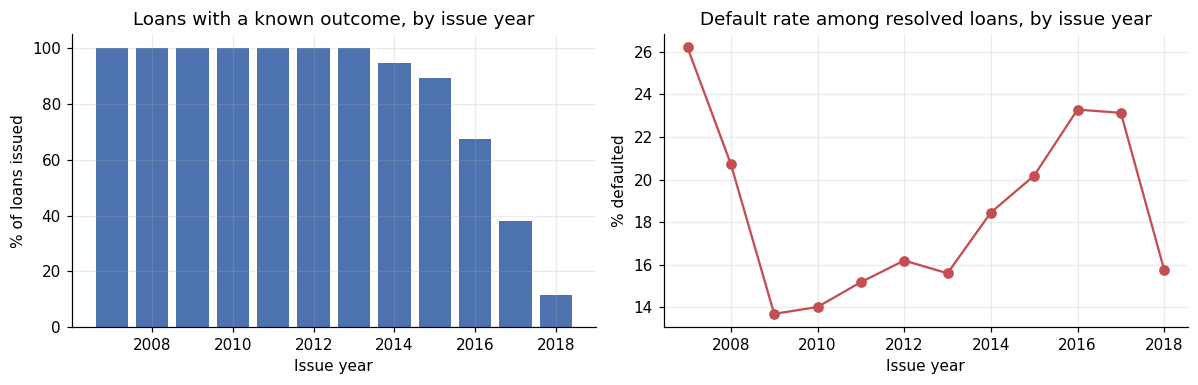

First issue year below 90% known outcomes: 2015
Sample window: loans issued up to 2014 (applied in section 9)


In [110]:
issue_year = pd.to_datetime(df[SPLIT_KEY]).dt.year

vintage = pd.DataFrame({"year": issue_year, "resolved": resolved}).groupby("year")["resolved"].agg(
    loans="size", resolved_share=lambda s: s.mean() * 100
)
vintage["default_rate_%"] = (
    df_model.groupby(pd.to_datetime(df_model[SPLIT_KEY]).dt.year)[TARGET].mean() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].bar(vintage.index, vintage["resolved_share"], color="#4C72B0")
axes[0].set_title("Loans with a known outcome, by issue year")
axes[0].set_ylabel("% of loans issued")

axes[1].plot(vintage.index, vintage["default_rate_%"], marker="o", color="#C44E52")
axes[1].set_title("Default rate among resolved loans, by issue year")
axes[1].set_ylabel("% defaulted")

for ax in axes:
    ax.set_xlabel("Issue year")

plt.tight_layout()
plt.show()

vintage

# Sample window: keep only the years where most loans have a known outcome
MIN_RESOLVED_SHARE = 90  # percent

incomplete_years = vintage.index[vintage["resolved_share"] < MIN_RESOLVED_SHARE]
SAMPLE_END_YEAR = int(incomplete_years.min()) - 1 if len(incomplete_years) else int(vintage.index.max())

print(f"First issue year below {MIN_RESOLVED_SHARE}% known outcomes: {incomplete_years.min()}")
print(f"Sample window: loans issued up to {SAMPLE_END_YEAR} (applied in section 9)")

### 3.4 Sample window: loans issued up to 2014

**Decision.** I keep only the loans issued from 2007 up to 2014. Loans issued from 2015 to 2018 are removed. The filter is applied in section 9, so all checks before it use the full sample.

**The problem: recent loans have incomplete outcomes.**
In section 3.2 I removed every loan without a final outcome (`Current`, `In Grace Period`, `Late`). The labels of the remaining loans are correct, but this filter creates a problem for the recent years.

A LendingClub loan runs for 36 or 60 months. A loan issued in 2017 is still being repaid, so most loans from 2016 to 2018 are `Current` and were removed. The recent loans that remain are only the ones that finished early:
- **Charged off early:** borrowers who stopped paying in the first months.
- **Fully paid early:** borrowers who repaid the whole loan quickly.

The loans that will finish on schedule are missing. This is called **right-censoring**: the outcome is only visible for loans that ended quickly, so the remaining sample is **not representative** of the loans issued in those years.

**Evidence.** The table in section 3.3 shows the problem. The share of loans with a known outcome is high until 2014 (about 95%), starts to fall in 2015 (about 89%), and then drops sharply in 2016, 2017 and 2018 (about 11% in 2018). The default rate of these last years is therefore not comparable with the older years.

**Why this matters for the model.**
1. **The target changes its meaning by year.** A higher default rate in 2017 does not mean 2017 borrowers were riskier. It means that only early finishers are visible.
2. **A time-based split is affected.** The latest years would become the test set, so the evaluation would be done on exactly the biased years.
3. **The model can learn the wrong pattern.** It can learn "this type of loan finishes early" instead of "this type of borrower defaults".

**Trade-off.** I lose a large number of rows, but I get a target that has the same meaning in every year. I prefer reliable labels over more data. Loans up to 2014 have had enough time to finish, even though some 60-month loans from 2014 are still open.

**Side effect.** Several credit-history columns were introduced by the lender only in late 2015, so they are empty for loans issued up to 2014. Section 8 drops them for this reason.

**How to change it.** The cut-off is controlled by `MIN_RESOLVED_SHARE` in section 3.3 (currently 90%). With the current table, it gives loans issued up to 2014.

In [111]:
del df  # free memory: only the modelling dataset is needed from here on

## 4. Scope and column selection

### 4.1 Restrict to individual applications
The project models **individual applicants only**. Joint applications carry a second applicant's income, DTI and credit history, which would need a separate treatment, so they are out of scope.

In [112]:
print(df_model["application_type"].value_counts().to_string())

df_model = df_model.loc[df_model["application_type"] == "Individual"]
log_step("Restricted to individual applications", df_model)

print(f"\nRows after restriction: {len(df_model):,}")

application_type
Individual    1322292
Joint App       25806

Rows after restriction: 1,322,292


### 4.2 Column classification
Each column is assigned to a group, and each group has a keep/drop decision. `issue_d` is kept in its own group because it is needed for the time-based split, but it must **not** be used as a feature.

In [113]:
column_categories = {
    "Application Information": [
        "loan_amnt",
        "term",
        "emp_length",
        "home_ownership",
        "annual_inc",
        "verification_status",
        "purpose",
        "zip_code",
        "addr_state",
        "dti",
    ],

    "Credit History": [
        "delinq_2yrs",
        "earliest_cr_line",
        "fico_range_low",
        "fico_range_high",
        "inq_last_6mths",
        "mths_since_last_delinq",
        "mths_since_last_record",
        "open_acc",
        "pub_rec",
        "revol_bal",
        "revol_util",
        "total_acc",
        "collections_12_mths_ex_med",
        "mths_since_last_major_derog",
        "acc_now_delinq",
        "tot_coll_amt",
        "tot_cur_bal",
        "open_acc_6m",
        "open_act_il",
        "open_il_12m",
        "open_il_24m",
        "mths_since_rcnt_il",
        "total_bal_il",
        "il_util",
        "open_rv_12m",
        "open_rv_24m",
        "max_bal_bc",
        "all_util",
        "total_rev_hi_lim",
        "inq_fi",
        "total_cu_tl",
        "inq_last_12m",
        "acc_open_past_24mths",
        "avg_cur_bal",
        "bc_open_to_buy",
        "bc_util",
        "chargeoff_within_12_mths",
        "delinq_amnt",
        "mo_sin_old_il_acct",
        "mo_sin_old_rev_tl_op",
        "mo_sin_rcnt_rev_tl_op",
        "mo_sin_rcnt_tl",
        "mort_acc",
        "mths_since_recent_bc",
        "mths_since_recent_bc_dlq",
        "mths_since_recent_inq",
        "mths_since_recent_revol_delinq",
        "num_accts_ever_120_pd",
        "num_actv_bc_tl",
        "num_actv_rev_tl",
        "num_bc_sats",
        "num_bc_tl",
        "num_il_tl",
        "num_op_rev_tl",
        "num_rev_accts",
        "num_rev_tl_bal_gt_0",
        "num_sats",
        "num_tl_120dpd_2m",
        "num_tl_30dpd",
        "num_tl_90g_dpd_24m",
        "num_tl_op_past_12m",
        "pct_tl_nvr_dlq",
        "percent_bc_gt_75",
        "pub_rec_bankruptcies",
        "tax_liens",
        "tot_hi_cred_lim",
        "total_bal_ex_mort",
        "total_bc_limit",
        "total_il_high_credit_limit",
    ],

    "Joint Application / Credit History": [
        "application_type",
        "annual_inc_joint",
        "dti_joint",
        "verification_status_joint",
        "revol_bal_joint",
        "sec_app_fico_range_low",
        "sec_app_fico_range_high",
        "sec_app_earliest_cr_line",
        "sec_app_inq_last_6mths",
        "sec_app_mort_acc",
        "sec_app_open_acc",
        "sec_app_revol_util",
        "sec_app_open_act_il",
        "sec_app_num_rev_accts",
        "sec_app_chargeoff_within_12_mths",
        "sec_app_collections_12_mths_ex_med",
        "sec_app_mths_since_last_major_derog",
    ],

    "Lender-Assigned / Listing Attributes": [
        "int_rate",
        "installment",
        "grade",
        "sub_grade",
        "initial_list_status",
    ],

    "Funding / Loan Issuance": [
        "funded_amnt",
        "funded_amnt_inv",
        "disbursement_method",
    ],

    "Post-Loan Performance": [
        "out_prncp",
        "out_prncp_inv",
        "total_pymnt",
        "total_pymnt_inv",
        "total_rec_prncp",
        "total_rec_int",
        "total_rec_late_fee",
        "recoveries",
        "collection_recovery_fee",
        "last_pymnt_d",
        "last_pymnt_amnt",
        "next_pymnt_d",
        "last_credit_pull_d",
        "last_fico_range_high",
        "last_fico_range_low",
        "pymnt_plan",
    ],

    "Hardship / Payment Modification": [
        "hardship_flag",
        "hardship_type",
        "hardship_reason",
        "hardship_status",
        "deferral_term",
        "hardship_amount",
        "hardship_start_date",
        "hardship_end_date",
        "payment_plan_start_date",
        "hardship_length",
        "hardship_dpd",
        "hardship_loan_status",
        "orig_projected_additional_accrued_interest",
        "hardship_payoff_balance_amount",
        "hardship_last_payment_amount",
    ],

    "Debt Settlement": [
        "debt_settlement_flag",
        "debt_settlement_flag_date",
        "settlement_status",
        "settlement_date",
        "settlement_amount",
        "settlement_percentage",
        "settlement_term",
    ],

    "Identifiers / Administrative": [
        "id",
        "member_id",
        "url",
        "policy_code",
    ],

    "Text / Free Text": [
        "emp_title",
        "title",
        "desc",
    ],

    "Split Key": [
        SPLIT_KEY,
    ],

    "Target Source": [
        "loan_status",
    ],
}

category_decisions = {
    "Application Information": ("Keep", "Candidate feature"),
    "Credit History": ("Keep", "Candidate feature"),
    "Joint Application / Credit History": ("Drop", "Out of scope: individual applications only"),
    "Lender-Assigned / Listing Attributes": ("Drop", "Excluded from the feature set by design"),
    "Funding / Loan Issuance": ("Drop", "Excluded from the feature set by design"),
    "Post-Loan Performance": ("Drop", "Only known after origination (leakage)"),
    "Hardship / Payment Modification": ("Drop", "Only known after origination (leakage)"),
    "Debt Settlement": ("Drop", "Only known after origination (leakage)"),
    "Identifiers / Administrative": ("Drop", "No predictive meaning"),
    "Text / Free Text": ("Drop", "Free text, out of scope"),
    "Split Key": ("Keep", "Used for the time-based split only, not a feature"),
    "Target Source": ("Drop", f"Replaced by the binary `{TARGET}` target"),
}

classification_df = pd.DataFrame(
    [
        {
            "Column": col,
            "Category": category,
            "Decision": category_decisions[category][0],
            "Reason": category_decisions[category][1],
        }
        for category, columns in column_categories.items()
        for col in columns
    ]
)

# Every column must be classified exactly once
assert classification_df["Column"].is_unique, "A column appears in more than one category"
unclassified = set(df_model.columns) - set(classification_df["Column"]) - {TARGET}
absent = set(classification_df["Column"]) - set(df_model.columns)
assert not unclassified, f"Unclassified columns: {sorted(unclassified)}"
assert not absent, f"Classified columns not in the data: {sorted(absent)}"

(
    classification_df
    .groupby(["Category", "Decision", "Reason"], sort=False)
    .size()
    .rename("columns")
    .reset_index()
)

,Category,Decision,Reason,columns
0,Application Information,Keep,Candidate feature,10
1,Credit History,Keep,Candidate feature,69
2,Joint Application / Credit History,Drop,Out of scope: individual applications only,17
3,Lender-Assigned / Listing Attributes,Drop,Excluded from the feature set by design,5
4,Funding / Loan Issuance,Drop,Excluded from the feature set by design,3
5,Post-Loan Performance,Drop,Only known after origination (leakage),16
6,Hardship / Payment Modification,Drop,Only known after origination (leakage),15
7,Debt Settlement,Drop,Only known after origination (leakage),7
8,Identifiers / Administrative,Drop,No predictive meaning,4
9,Text / Free Text,Drop,"Free text, out of scope",3


### 4.3 Apply the column selection

In [114]:
drop_cols = classification_df.loc[classification_df["Decision"] == "Drop", "Column"].tolist()
df_model = df_model.drop(columns=drop_cols)
log_step("Column selection applied", df_model)

feature_cols = [c for c in df_model.columns if c not in (TARGET, SPLIT_KEY)]

print(f"Dropped {len(drop_cols)} columns")
print(f"Remaining: {len(feature_cols)} candidate features + target (`{TARGET}`) + split key (`{SPLIT_KEY}`)")

Dropped 71 columns
Remaining: 79 candidate features + target (`default`) + split key (`issue_d`)


## 5. Missingness assessment
Missing rates are reviewed for the candidate features only. Joint-application columns are gone, so the remaining missingness reflects individual loans.

In [115]:
HIGH_MISSING_THRESHOLD = 15  # percent

missing_pct = (df_model[feature_cols].isna().mean() * 100).sort_values(ascending=False)
missing_summary = missing_pct.rename("missing_%").to_frame()
missing_summary["group"] = np.where(
    missing_pct > HIGH_MISSING_THRESHOLD, f"High (> {HIGH_MISSING_THRESHOLD}%)", f"Low (<= {HIGH_MISSING_THRESHOLD}%)"
)

print(missing_summary["group"].value_counts().to_string())
print(f"Features with no missing values: {(missing_pct == 0).sum()}")

group
Low (<= 15%)    60
High (> 15%)    19
Features with no missing values: 11


### 5.1 High missingness (> 15%)
These features measure the time elapsed since a credit event, or were reported only for part of the period. Their missingness may carry meaning, so they are **not** removed on the missing rate alone.

Several columns share exactly the same missing rate (see below), which suggests they were introduced together for later loans (structural missingness) rather than being missing at random.

In [116]:
high_missing = missing_summary[missing_summary["group"].str.startswith("High")]

display(high_missing[["missing_%"]].style.format("{:.2f}").bar(color="#9ecae1", vmin=0, vmax=100))

shared_rates = high_missing["missing_%"].round(2).value_counts()
print("Missing rates shared by more than one column:")
print(shared_rates[shared_rates > 1].rename("columns").to_string())

,missing_%
mths_since_last_record,83.00
mths_since_recent_bc_dlq,76.29
mths_since_last_major_derog,73.71
mths_since_recent_revol_delinq,66.58
il_util,66.44
mths_since_rcnt_il,62.29
all_util,61.27
open_acc_6m,61.27
total_cu_tl,61.27
inq_last_12m,61.27


Missing rates shared by more than one column:
missing_%
61.27    12


Whether a missing value means "no such event", "not applicable" or "not recorded" will be decided with EDA and domain evidence, before choosing an imputation strategy.

### 5.2 Low missingness (<= 15%)
Missing values are limited, so these features are kept and handled with imputation in the preprocessing pipeline (fitted on the training data only).

In [117]:
low_missing = missing_summary[(missing_summary["group"].str.startswith("Low")) & (missing_summary["missing_%"] > 0)]
low_missing[["missing_%"]]

,missing_%
mths_since_recent_inq,13.18
num_tl_120dpd_2m,9.09
mo_sin_old_il_acct,8.13
emp_length,5.66
pct_tl_nvr_dlq,5.33
avg_cur_bal,5.32
num_rev_accts,5.31
mo_sin_old_rev_tl_op,5.31
mo_sin_rcnt_rev_tl_op,5.31
num_il_tl,5.31


### 5.3 When is each high-missing column filled?
To separate the two types of missingness, I look at the missing rate of each high-missing column by issue year.

- If a column is empty for the old years and filled later, the lender did not report it for older loans. This is **structural missingness**, and it says nothing about the borrower.
- If the missing rate stays about the same in every year, the value is missing because the event did not happen (for example, no delinquency). This is **event-based missingness**, and the missing flag itself can carry information.

In [118]:
issue_year_model = pd.to_datetime(df_model[SPLIT_KEY]).dt.year

missing_by_year = (
    df_model[high_missing.index].isna()
    .groupby(issue_year_model)
    .mean()
    .mul(100)
)

(
    missing_by_year.T
    .style.format("{:.0f}")
    .background_gradient(cmap="Blues", axis=None, vmin=0, vmax=100)
)

issue_d,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018
mths_since_last_record,7,61,95,94,95,97,88,82,82,80,80,85
mths_since_recent_bc_dlq,100,100,100,100,100,87,78,74,74,75,76,79
mths_since_last_major_derog,100,100,100,100,100,90,80,72,70,71,72,75
mths_since_recent_revol_delinq,100,100,100,100,100,74,70,64,64,64,66,70
il_util,100,100,100,100,100,100,100,100,96,13,13,16
mths_since_rcnt_il,100,100,100,100,100,100,100,100,95,3,3,3
all_util,100,100,100,100,100,100,100,100,95,0,0,0
open_acc_6m,100,100,100,100,100,100,100,100,95,0,0,0
total_cu_tl,100,100,100,100,100,100,100,100,95,0,0,0
inq_last_12m,100,100,100,100,100,100,100,100,95,0,0,0


- Year-wise missingness reveals that many high-missingness variables are structurally unavailable for older loans, particularly variables introduced around 2015–2016. In contrast, delinquency/derogatory-history variables remain missing across years and are more consistent with event-based missingness. Therefore, missingness mechanism—not overall missing percentage alone—should guide feature retention and treatment.

## 6. Data types and categorical fields

### 6.1 Current data types

In [119]:
print(df_model[feature_cols].dtypes.value_counts().to_string())

text_cols = df_model[feature_cols].select_dtypes(include=["object", "string"]).columns
pd.DataFrame({
    "dtype": df_model[text_cols].dtypes.astype(str),
    "unique_values": df_model[text_cols].nunique(),
    "missing_%": df_model[text_cols].isna().mean() * 100,
})

float64           71
object             7
datetime64[ns]     1


,dtype,unique_values,missing_%
term,object,2,0.00
emp_length,object,11,5.66
home_ownership,object,6,0.00
verification_status,object,3,0.00
purpose,object,14,0.00
zip_code,object,945,0.00
addr_state,object,51,0.00


### 6.2 `term`
`term` has only two values (`36 months` and `60 months`), so I convert it to the number of months.

In [120]:
df_model['term'].nunique()

2

In [121]:
df_model['term'] = (
    df_model['term']
    .str.extract(r'(\d+)')[0]
    .astype(int)
)

### 6.3 `emp_length`
`emp_length` is text, but it has a natural order. I map it to a number from 0 (`< 1 year`) to 10 (`10+ years`), so the order is kept. Missing values stay as `NaN`; they get their own indicator in section 8.

In [122]:
df_model['emp_length'].unique()

array(['10+ years', '3 years', '4 years', '6 years', '7 years', '8 years',
       '2 years', '5 years', '9 years', '< 1 year', '1 year', None],
      dtype=object)

In [123]:
EMP_LENGTH_MAP = {
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10,
}

unmapped = set(df_model["emp_length"].dropna().unique()) - set(EMP_LENGTH_MAP)
assert not unmapped, f"Unmapped emp_length values: {unmapped}"

df_model["emp_length"] = df_model["emp_length"].map(EMP_LENGTH_MAP)
df_model["emp_length"].value_counts(dropna=False).sort_index()

emp_length
0.00     103017
1.00      87620
2.00     120224
3.00     106285
4.00      79517
5.00      83099
6.00      62066
7.00      59019
8.00      60114
9.00      50417
10.00    436112
NaN       74802
Name: count, dtype: int64

### 6.4 Other categorical columns
I look at the values of the remaining text columns. `zip_code` and `addr_state` are checked later in their own sections.

In [124]:
object_to_category = [
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
]

for col in ["home_ownership", "verification_status", "purpose"]:
    print(df_model[col].value_counts().to_string(), end="\n\n")

# Text standardisation check: leading/trailing spaces
whitespace_issues = {
    col: int((df_model[col] != df_model[col].str.strip()).sum()) for col in object_to_category
}
print("Values with extra spaces:", whitespace_issues)

home_ownership
MORTGAGE    649377
RENT        529785
OWN         142611
ANY            286
OTHER          182
NONE            51

verification_status
Source Verified    514178
Verified           408973
Not Verified       399141

purpose
debt_consolidation    765468
credit_card           291186
home_improvement       85672
other                  76855
major_purchase         29055
small_business         15341
medical                15157
car                    14446
moving                  9335
vacation                8953
house                   7130
wedding                 2350
renewable_energy         921
educational              423

Values with extra spaces: {'home_ownership': 0, 'verification_status': 0, 'purpose': 0, 'addr_state': 0}


The text values are already clean. The only issue is `home_ownership`: `ANY` and `NONE` are almost empty categories and `OTHER` is also very small. They all mean "not rent, own or mortgage", so I merge them into `OTHER`. This is a fixed rule that does not depend on the target, so it is safe to do before the split.

Then I convert these columns to the `category` type.

In [125]:
df_model["home_ownership"] = df_model["home_ownership"].replace({"ANY": "OTHER", "NONE": "OTHER"})
print(df_model["home_ownership"].value_counts().to_string())

home_ownership
MORTGAGE    649377
RENT        529785
OWN         142611
OTHER          519


In [126]:
df_model[object_to_category] = df_model[object_to_category].astype('category')

### 6.5 `zip_code`

`zip_code` has 945 different values, so each ZIP code has very few loans. I replace it with its first digit (for example, `5` means every ZIP code that starts with 5). The first digit is a broad region of the US, so I keep some geographic information and reduce the number of categories a lot.

In [127]:
# Aggregate sparse ZIP codes by their first digit (e.g. 5 = all 5xxxx ZIP codes).
df_model["zip_code"] = (
    df_model["zip_code"]
    .astype("string")
    .str.extract(r"^(\d)", expand=False)
    .fillna("Unknown")
    .astype("category")
)

zip_default_summary = (
    df_model.groupby("zip_code", observed=False)[TARGET]
    .agg(loans="size", default_rate="mean")
    .sort_index()
)
zip_default_summary["loan_share_%"] = zip_default_summary["loans"] / len(df_model) * 100
zip_default_summary.assign(default_rate=lambda x: x["default_rate"] * 100).round(2)

,loans,default_rate,loan_share_%
zip_code,,,
0,114796,19.06,8.68
1,157176,21.51,11.89
2,129530,19.63,9.80
3,179573,21.02,13.58
4,111456,20.57,8.43
5,48745,19.04,3.69
6,86103,18.91,6.51
7,144976,20.65,10.96
8,101932,18.67,7.71


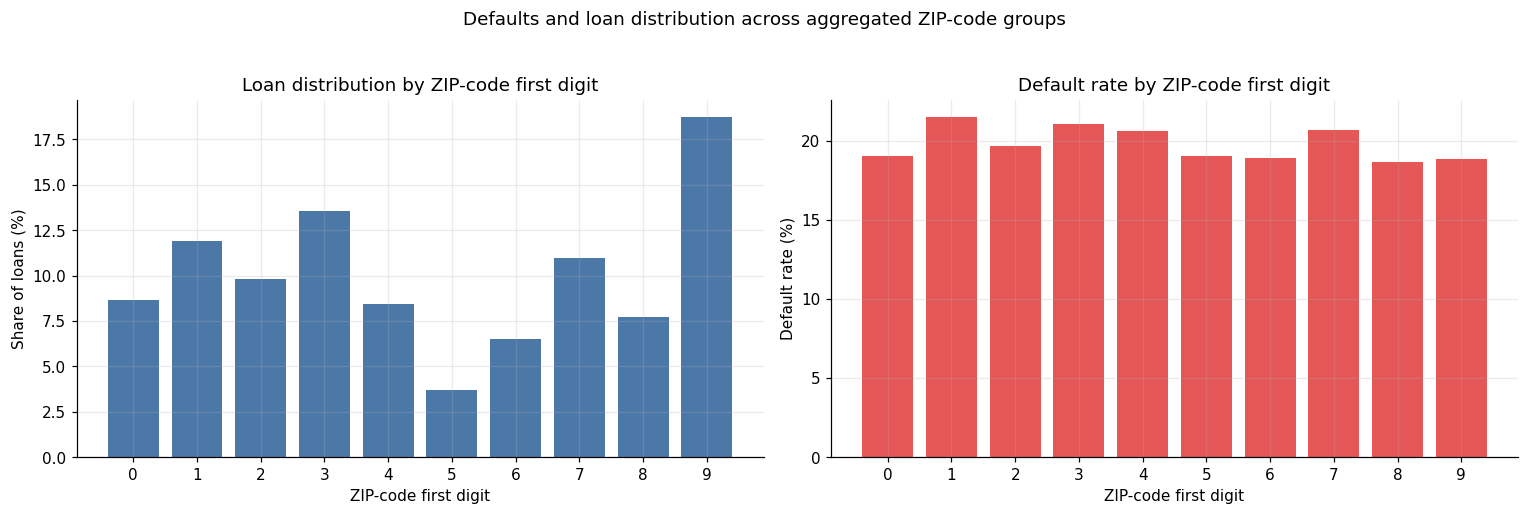

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)

axes[0].bar(zip_default_summary.index.astype(str), zip_default_summary["loan_share_%"], color="#4C78A8")
axes[0].set_title("Loan distribution by ZIP-code first digit")
axes[0].set_xlabel("ZIP-code first digit")
axes[0].set_ylabel("Share of loans (%)")

axes[1].bar(zip_default_summary.index.astype(str), zip_default_summary["default_rate"] * 100, color="#E45756")
axes[1].set_title("Default rate by ZIP-code first digit")
axes[1].set_xlabel("ZIP-code first digit")
axes[1].set_ylabel("Default rate (%)")

fig.suptitle("Defaults and loan distribution across aggregated ZIP-code groups", y=1.03)
plt.tight_layout()
plt.show()

The default rate is fairly similar across the ten groups (about 18.7% to 21.5%). This table is only descriptive. I do not use it to decide anything, because a choice based on the default rate must be made on the training data only.

### 6.6 `addr_state`

In [129]:
(df_model["addr_state"].value_counts(normalize=True) * 100).round(2)

addr_state
CA   14.64
NY    8.22
TX    8.17
FL    7.12
IL    3.86
NJ    3.63
PA    3.39
OH    3.25
GA    3.24
VA    2.83
NC    2.81
MI    2.62
AZ    2.41
MD    2.33
MA    2.31
CO    2.19
WA    2.16
MN    1.78
IN    1.60
MO    1.57
TN    1.50
NV    1.50
CT    1.48
WI    1.31
AL    1.24
OR    1.21
SC    1.19
LA    1.15
KY    0.95
OK    0.90
KS    0.83
AR    0.74
UT    0.74
NM    0.55
HI    0.50
MS    0.49
NH    0.48
RI    0.44
WV    0.37
DE    0.28
MT    0.28
DC    0.26
NE    0.26
AK    0.24
WY    0.21
SD    0.20
VT    0.20
ME    0.15
ND    0.11
ID    0.11
IA    0.00
Name: proportion, dtype: float64

Borrowers are spread unevenly across the states. California has the largest share (14.64%), followed by New York (8.22%), Texas (8.17%) and Florida (7.12%). These four states together hold 38.15% of the loans.

I considered grouping the states into high-, medium- and low-frequency groups to reduce the number of categories, but I keep the original state for now. If I group states using the default rate, I must learn the groups on the training data only, so I decide this in feature engineering after the split.

## 7. Value validity
I check the numeric columns that can contain impossible or doubtful values. Impossible values are set to `NaN`. Values that are extreme but possible are kept, and I treat them after the split.

### 7.1 `dti` (debt-to-income ratio)

In [130]:
df_model['dti'].describe()

count   1,322,292.00
mean           18.01
std             8.37
min            -1.00
25%            11.74
50%            17.52
75%            23.89
max            49.96
Name: dti, dtype: float64

In [131]:
df_model[df_model['dti']<0] 

,loan_amnt,term,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,default
1014615,"15,000.00",36,5.00,MORTGAGE,"94,000.00",Source Verified,2016-03-01,debt_consolidation,9,OR,-1.00,0.00,2003-09-01,670.00,674.00,0.00,63.00,66.00,12.00,1.00,"15,445.00",45.80,24.00,0.00,63.00,0.00,0.00,"93,070.00",1.00,3.00,1.00,4.00,10.00,"77,625.00",90.00,2.00,4.00,"4,108.00",73.00,"33,700.00",1.00,10.00,2.00,8.00,"8,461.00","3,942.00",61.70,0.00,0.00,98.00,150.00,2.00,2.00,1.00,15.00,63.00,10.00,63.00,0.00,3.00,5.00,3.00,6.00,10.00,9.00,13.00,5.00,11.00,0.00,0.00,0.00,3.00,95.80,33.30,1.00,0.00,"127,743.00","93,070.00","10,300.00","94,043.00",0


In [132]:
(df_model['dti'] < 0).sum()

np.int64(1)

`dti` is the monthly debt payments of the borrower (without the mortgage and the requested loan) divided by their self-reported monthly income. A ratio like this cannot be negative, so a negative value is invalid.

There is only one such loan (`dti = -1`). Its `annual_inc` is valid, so the problem is only in `dti`, and the `-1` looks like a placeholder for a missing value.

I replace it with `NaN` and not with `0`. A `0` is a real DTI (no debt payments), and it would hide the difference between "no debt" and "unknown". The missing value is imputed later, after the split.

In [133]:
df_model['dti'] = df_model['dti'].mask(df_model['dti'] < 0, np.nan)

### 7.2 `annual_inc`

In [134]:
df_model['annual_inc'].describe()

count    1,322,288.00
mean        76,599.18
std         70,332.80
min          1,896.00
25%         46,000.00
50%         65,000.00
75%         90,636.00
max     10,999,200.00
Name: annual_inc, dtype: float64

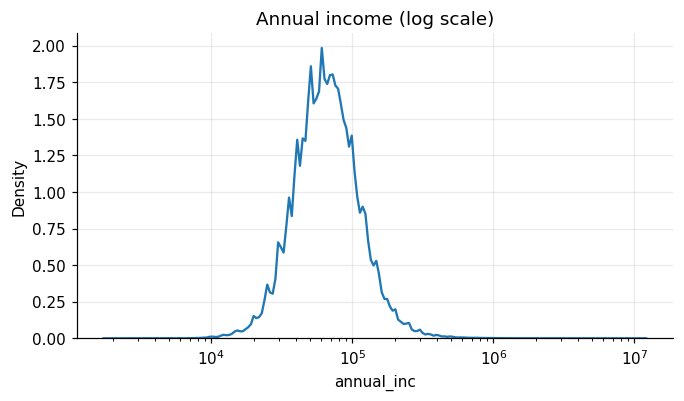

In [135]:
fig, ax = plt.subplots(figsize=(7, 3.6))
sns.kdeplot(df_model["annual_inc"], log_scale=True, ax=ax)
ax.set_title("Annual income (log scale)")
plt.show()

`annual_inc` is strongly right-skewed. The median is $65,000, but the mean is $76,599, and the maximum is $10,999,200, which creates a very long right tail. The minimum is $1,896, so there is no zero or negative income.

I keep the extreme values, because a very high income can be real. If I need capping or a log transform, I fit it on the training data after the split.

### 7.3 `revol_util`
`revol_util` is the percentage of the revolving credit limit that the borrower is using now. I check it against the value calculated from the balance and the limit: `revol_bal / total_rev_hi_lim × 100`.

In [136]:
df_model['revol_util'].describe()

count   1,321,440.00
mean           51.87
std            24.50
min             0.00
25%            33.50
50%            52.20
75%            70.80
max           892.30
Name: revol_util, dtype: float64

<Axes: xlabel='revol_util', ylabel='Density'>

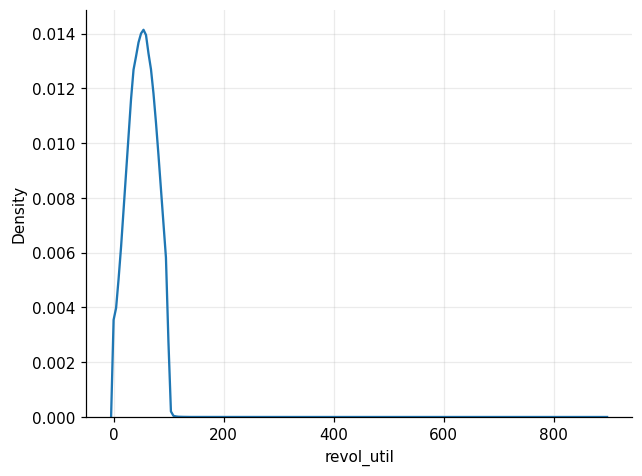

In [137]:
import seaborn as sns

sns.kdeplot(df_model['revol_util'])

In [138]:
(df_model["revol_util"] > 100).sum()

np.int64(4638)

In [139]:
util_cols = ["revol_util", "revol_bal", "total_rev_hi_lim"]

# Loans where revol_util is inside 0-100
df_check = df_model.loc[
    df_model["revol_util"].between(0, 100) & (df_model["total_rev_hi_lim"] > 0),
    util_cols,
].copy()

df_check["revol_util_calculated"] = df_check["revol_bal"] / df_check["total_rev_hi_lim"] * 100
df_check["difference"] = df_check["revol_util"] - df_check["revol_util_calculated"]

print(df_check["difference"].describe().to_string())
print(f"\nWithin 1 percentage point: {(df_check['difference'].abs() <= 1).mean() * 100:.2f}%")

count   1,246,671.00
mean           -0.33
std             4.70
min          -311.39
25%            -0.03
50%             0.00
75%             0.03
max            95.36

Within 1 percentage point: 95.78%


In [140]:
# Loans where revol_util is above 100
df_over_100 = df_model.loc[
    (df_model["revol_util"] > 100) & (df_model["total_rev_hi_lim"] > 0),
    util_cols,
].copy()

df_over_100["revol_util_calculated"] = df_over_100["revol_bal"] / df_over_100["total_rev_hi_lim"] * 100
df_over_100["difference"] = df_over_100["revol_util"] - df_over_100["revol_util_calculated"]

print(df_over_100["difference"].describe().to_string())
print(f"\nWithin 1 percentage point: {(df_over_100['difference'].abs() <= 1).mean() * 100:.2f}%")

df_over_100.head(10)

count   4,611.00
mean        0.77
std         6.09
min       -43.96
25%        -0.03
50%         0.00
75%         0.03
max        97.24

Within 1 percentage point: 95.60%


,revol_util,revol_bal,total_rev_hi_lim,revol_util_calculated,difference
23,101.50,"9,441.00","9,300.00",101.52,-0.02
202,102.00,"18,255.00","17,900.00",101.98,0.02
249,100.60,"18,114.00","18,000.00",100.63,-0.03
721,100.30,"4,014.00","4,000.00",100.35,-0.05
1127,100.10,"23,021.00","23,000.00",100.09,0.01
1143,100.30,"3,010.00","3,000.00",100.33,-0.03
1948,101.10,"7,985.00","7,900.00",101.08,0.02
2359,100.70,"13,902.00","13,800.00",100.74,-0.04
2449,102.00,"13,049.00","12,750.00",102.35,-0.35
2568,100.20,"6,612.00","6,600.00",100.18,0.02


In [141]:
large_gap = df_over_100.loc[df_over_100["difference"].abs() > 1]

print(f"Loans with a gap above 1 percentage point: {len(large_gap)}")
print(large_gap["difference"].describe().to_string())

large_gap.sort_values("difference", key=abs, ascending=False).head(20)

Loans with a gap above 1 percentage point: 203
count   203.00
mean     17.46
std      23.50
min     -43.96
25%       1.84
50%       7.67
75%      27.81
max      97.24


,revol_util,revol_bal,total_rev_hi_lim,revol_util_calculated,difference
414612,184.60,"266,444.00","305,000.00",87.36,97.24
214045,102.30,"3,363.00","47,000.00",7.16,95.14
1389199,104.40,"6,262.00","44,000.00",14.23,90.17
133379,100.20,"36,198.00","270,600.00",13.38,86.82
2173536,100.10,"21,548.00","105,000.00",20.52,79.58
388970,100.10,"10,301.00","50,000.00",20.60,79.50
160620,101.20,"21,974.00","81,500.00",26.96,74.24
342967,102.10,"9,081.00","32,000.00",28.38,73.72
1078434,100.30,"12,539.00","45,500.00",27.56,72.74
1322969,103.50,"31,036.00","100,000.00",31.04,72.46


- For `revol_util` between 0 and 100, 95.78% of the values are within 1 percentage point of the calculated utilization.
- For `revol_util` above 100 (4,638 loans), 95.60% are also within 1 percentage point. A borrower can have a balance higher than the limit, so a value above 100% is not automatically wrong.
- 203 loans show a larger gap, so `total_rev_hi_lim` cannot always rebuild `revol_util`.

**Decision.** I keep the original `revol_util`. I do not replace it with the calculated value, and I do not treat values above 100% as invalid. Very large values (the maximum is 892.3) are handled after the split with capping fitted on the training data.

### 7.4 FICO score range

In [142]:
df_model['fico_range_low'].describe()

count   1,322,292.00
mean          696.00
std            31.70
min           610.00
25%           670.00
50%           690.00
75%           710.00
max           845.00
Name: fico_range_low, dtype: float64

In [143]:
df_model['fico_range_high'].describe()

count   1,322,292.00
mean          700.00
std            31.71
min           614.00
25%           674.00
50%           694.00
75%           714.00
max           850.00
Name: fico_range_high, dtype: float64

In [144]:
(df_model['fico_range_low'] > df_model['fico_range_high']).sum()

np.int64(0)

In [145]:
(df_model['fico_range_high'] - df_model['fico_range_low']).value_counts().sort_index()

4.00    1322119
5.00        173
Name: count, dtype: int64

Both columns are inside the valid FICO range of 300–850: `fico_range_low` goes from 610 to 845 and `fico_range_high` from 614 to 850. `fico_range_low` is never above `fico_range_high` (0 cases), and the gap between them is always 4 or 5 points, so the ranges are defined consistently.

I keep both columns without any change. Because the gap is almost fixed, they carry almost the same information, so in feature engineering I will decide whether to keep both or combine them.

### 7.5 Other numeric columns
The same logic applies to the other columns. Counts, amounts, balances, ratios and "months since" values cannot be negative, the two percentage columns must be between 0 and 100, and a credit line cannot start after the loan was issued. Any value that breaks these rules is impossible, so I set it to `NaN`.

In [146]:
numeric_features = df_model[feature_cols].select_dtypes("number").columns
percent_cols = ["pct_tl_nvr_dlq", "percent_bc_gt_75"]

# Negative values
negative_counts = (df_model[numeric_features] < 0).sum()
negative_counts = negative_counts[negative_counts > 0]

# Percentages outside 0-100
over_100_counts = (df_model[percent_cols] > 100).sum()
over_100_counts = over_100_counts[over_100_counts > 0]

# Credit line that starts after the loan was issued
bad_date = df_model["earliest_cr_line"] > df_model[SPLIT_KEY]

print("Columns with negative values:", negative_counts.to_dict() or "none")
print("Percentage columns above 100:", over_100_counts.to_dict() or "none")
print("Credit line after issue date:", int(bad_date.sum()))

for col in negative_counts.index:
    df_model[col] = df_model[col].mask(df_model[col] < 0)
for col in over_100_counts.index:
    df_model[col] = df_model[col].mask(df_model[col] > 100)
df_model["earliest_cr_line"] = df_model["earliest_cr_line"].mask(bad_date)

Columns with negative values: none
Percentage columns above 100: none
Credit line after issue date: 0


## 8. Missing-value handling
For each group of columns I choose between removal, a missing-value indicator and imputation. An indicator only needs `isna()`, so it can be created now. Imputation learns a value from the data, so it is done after the split.

### 8.1 High-missing columns
I use the sample window from section 3.3 and look at the high-missing columns (section 5.1) inside it.

- **Unusable:** the column is at least 99% missing inside the sample window. It has almost no values to learn from, so I drop it.
- **Usable:** the column has enough values. I keep it, add a `<column>_missing` indicator (the missing flag can be informative), and impute the value after the split.

In [147]:
UNUSABLE_THRESHOLD = 99  # percent missing inside the sample window

in_window = pd.to_datetime(df_model[SPLIT_KEY]).dt.year <= SAMPLE_END_YEAR
high_cols = high_missing.index.tolist()

window_missing = df_model.loc[in_window, high_cols].isna().mean() * 100

high_decision = pd.DataFrame({
    "missing_% (all years)": high_missing["missing_%"],
    "missing_% (sample window)": window_missing,
})
high_decision["decision"] = np.where(
    window_missing >= UNUSABLE_THRESHOLD, "Drop (unusable)", "Keep + indicator"
)

unusable_cols = high_decision.index[high_decision["decision"] == "Drop (unusable)"].tolist()
indicator_cols = high_decision.index[high_decision["decision"] == "Keep + indicator"].tolist()

high_decision

,missing_% (all years),missing_% (sample window),decision
mths_since_last_record,83.00,86.54,Keep + indicator
mths_since_recent_bc_dlq,76.29,78.88,Keep + indicator
mths_since_last_major_derog,73.71,78.84,Keep + indicator
mths_since_recent_revol_delinq,66.58,70.30,Keep + indicator
il_util,66.44,100.00,Drop (unusable)
mths_since_rcnt_il,62.29,100.00,Drop (unusable)
all_util,61.27,100.00,Drop (unusable)
open_acc_6m,61.27,100.00,Drop (unusable)
total_cu_tl,61.27,100.00,Drop (unusable)
inq_last_12m,61.27,100.00,Drop (unusable)


- I use the sample window defined in Section 3.3 because feature usability should be evaluated on the observations that will actually enter the modeling dataset.

- For each high-missing column, I calculate its missing percentage within this window.

- Unusable: If at least 99% of values are missing within the sample window, I drop the column because it contains too little observed information for modeling.

- Usable: Otherwise, I retain the column and create a <column>_missing indicator. The indicator captures whether the original value was missing and may provide predictive information, regardless of whether the missingness is structural, event-based, or a combination of both. The original value will be imputed after the train/test split to prevent information leakage.

### 8.2 `emp_length`
`emp_length` has a small share of missing values (5.66%). The plan is to keep the missing case as its own category, so I add an indicator and impute the number after the split.

### 8.3 Apply the decisions

In [148]:
indicators = {f"{col}_missing": df_model[col].isna().astype("int8") for col in indicator_cols + ["emp_length"]}

df_model = df_model.drop(columns=unusable_cols).assign(**indicators)
feature_cols = [c for c in df_model.columns if c not in (TARGET, SPLIT_KEY)]

log_step("Missing-value handling applied", df_model)

print(f"Dropped {len(unusable_cols)} unusable columns")
print(f"Added {len(indicators)} missing-value indicators")
print(f"Features now: {len(feature_cols)}")

Dropped 14 unusable columns
Added 6 missing-value indicators
Features now: 71


All other columns have a low missing rate. I keep them as they are and impute them in the preprocessing pipeline after the split, with values learned on the training data only.

## 9. Sample window
This is the last row filter. I apply the window chosen in section 3.3 and explained in section 3.4: only loans issued up to `SAMPLE_END_YEAR` are kept.

In [149]:
rows_before = len(df_model)

df_model = df_model.loc[pd.to_datetime(df_model[SPLIT_KEY]).dt.year <= SAMPLE_END_YEAR].copy()
log_step(f"Sample window applied (issued up to {SAMPLE_END_YEAR})", df_model)

print(f"Rows removed: {rows_before - len(df_model):,}")
print(f"Rows kept:    {len(df_model):,}")
print(f"Issue dates:  {df_model[SPLIT_KEY].min():%Y-%m} to {df_model[SPLIT_KEY].max():%Y-%m}")
print(f"Default rate: {df_model[TARGET].mean() * 100:.2f}%")

Rows removed: 868,483
Rows kept:    453,809
Issue dates:  2007-06 to 2014-12
Default rate: 17.03%


In [150]:
final_missing = (df_model[feature_cols].isna().mean() * 100).sort_values(ascending=False)

print("Highest missing rates after the window:")
print(final_missing[final_missing > 0].head(10).round(2).to_string())

assert final_missing.max() < UNUSABLE_THRESHOLD, "A feature is still almost empty inside the window"

Highest missing rates after the window:
mths_since_last_record           86.54
mths_since_recent_bc_dlq         78.88
mths_since_last_major_derog      78.84
mths_since_recent_revol_delinq   70.30
mths_since_last_delinq           53.80
mths_since_recent_inq            19.96
mo_sin_old_il_acct               18.36
num_tl_120dpd_2m                 17.23
pct_tl_nvr_dlq                   15.52
avg_cur_bal                      15.49


## 10. Save and summary

### 10.1 Save the cleaned dataset

In [151]:
df_model.to_parquet(OUTPUT_PATH, index=False)
log_step("Saved", df_model)

# Read the file back to confirm it is saved correctly
saved = pd.read_parquet(OUTPUT_PATH)
assert saved.shape == df_model.shape, "Saved file has a different shape"
assert list(saved.columns) == list(df_model.columns), "Saved file has different columns"

print(f"Saved {saved.shape[0]:,} rows x {saved.shape[1]} columns to {OUTPUT_PATH}")

Saved 453,809 rows x 73 columns to ..\data\interim\lendingclub_clean.parquet


### 10.2 Row and column counts after each step

In [152]:
steps = pd.DataFrame(step_log)
steps["rows_removed"] = (-steps["rows"].diff()).fillna(0).astype(int)
steps["columns_removed"] = (-steps["columns"].diff()).fillna(0).astype(int)
steps.style.format({"rows": "{:,}", "rows_removed": "{:,}"})

,step,rows,columns,rows_removed,columns_removed
0,Raw data loaded,"2,260,701",151,0,0
1,Invalid summary rows removed,"2,260,667",151,34,0
2,Duplicates checked,"2,260,667",151,0,0
3,Loans without a known outcome removed; target created,"1,348,098",152,"912,569",-1
4,Restricted to individual applications,"1,322,292",152,"25,806",0
5,Column selection applied,"1,322,292",81,0,71
6,Missing-value handling applied,"1,322,292",73,0,8
7,Sample window applied (issued up to 2014),"453,809",73,"868,483",0
8,Saved,"453,809",73,0,0


In [153]:
print(df_model[feature_cols].dtypes.value_counts().to_string())

df_model.head()

float64           58
int8               6
int64              1
category           1
category           1
category           1
category           1
category           1
datetime64[ns]     1


,loan_amnt,term,emp_length,home_ownership,annual_inc,verification_status,issue_d,purpose,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,default,mths_since_last_record_missing,mths_since_recent_bc_dlq_missing,mths_since_last_major_derog_missing,mths_since_recent_revol_delinq_missing,mths_since_last_delinq_missing,emp_length_missing
1117060,"10,400.00",36,8.00,MORTGAGE,"58,000.00",Not Verified,2014-12-01,credit_card,9,CA,14.92,0.00,1989-09-01,710.00,714.00,2.00,42.00,NaN,17.00,0.00,"6,133.00",31.60,36.00,0.00,59.00,0.00,0.00,"162,110.00","19,400.00",7.00,"9,536.00","7,599.00",41.50,0.00,0.00,76.00,290.00,1.00,1.00,1.00,5.00,42.00,1.00,42.00,4.00,6.00,9.00,7.00,18.00,2.00,14.00,32.00,9.00,17.00,0.00,0.00,0.00,4.00,83.30,14.30,0.00,0.00,"179,407.00","15,030.00","13,000.00","11,325.00",1,1,0,0,0,0,0
1117061,"15,000.00",60,10.00,RENT,"78,000.00",Source Verified,2014-12-01,debt_consolidation,2,VA,12.03,0.00,1994-08-01,750.00,754.00,0.00,NaN,NaN,6.00,0.00,"138,008.00",29.00,17.00,0.00,NaN,0.00,0.00,"149,140.00","184,500.00",5.00,"29,828.00","9,525.00",4.70,0.00,0.00,103.00,244.00,1.00,1.00,0.00,47.00,NaN,NaN,NaN,0.00,1.00,4.00,1.00,2.00,8.00,5.00,9.00,4.00,6.00,0.00,0.00,0.00,4.00,100.00,0.00,0.00,0.00,"196,500.00","149,140.00","10,000.00","12,000.00",0,1,1,1,1,1,0
1117062,"9,600.00",36,10.00,RENT,"69,000.00",Source Verified,2014-12-01,debt_consolidation,0,NJ,25.81,0.00,1992-11-01,680.00,684.00,0.00,NaN,NaN,12.00,0.00,"16,388.00",59.40,44.00,0.00,NaN,0.00,0.00,"38,566.00","27,600.00",8.00,"3,214.00","6,494.00",69.20,0.00,0.00,183.00,265.00,23.00,3.00,0.00,24.00,NaN,17.00,NaN,0.00,4.00,7.00,5.00,16.00,17.00,8.00,26.00,7.00,12.00,0.00,0.00,0.00,3.00,100.00,60.00,0.00,0.00,"52,490.00","38,566.00","21,100.00","24,890.00",0,1,1,1,1,1,0
1117063,"7,650.00",36,0.00,RENT,"50,000.00",Source Verified,2014-12-01,debt_consolidation,8,AZ,34.81,0.00,2002-08-01,685.00,689.00,1.00,NaN,NaN,11.00,0.00,"16,822.00",91.90,20.00,0.00,NaN,0.00,0.00,"64,426.00","18,300.00",6.00,"5,857.00",332.00,93.20,0.00,0.00,137.00,148.00,8.00,8.00,0.00,17.00,NaN,3.00,NaN,0.00,1.00,4.00,1.00,4.00,12.00,4.00,8.00,4.00,11.00,0.00,0.00,0.00,2.00,100.00,100.00,0.00,0.00,"82,331.00","64,426.00","4,900.00","64,031.00",1,1,1,1,1,1,0
1117065,"21,425.00",60,6.00,RENT,"63,800.00",Source Verified,2014-12-01,credit_card,6,MO,18.49,0.00,2003-08-01,685.00,689.00,0.00,60.00,NaN,10.00,0.00,"16,374.00",76.20,35.00,0.00,74.00,0.00,0.00,"42,315.00","21,500.00",4.00,"4,232.00",324.00,97.80,0.00,0.00,135.00,136.00,7.00,7.00,0.00,7.00,60.00,7.00,60.00,1.00,3.00,4.00,3.00,12.00,16.00,5.00,18.00,4.00,10.00,0.00,0.00,0.00,2.00,91.40,100.00,0.00,0.00,"57,073.00","42,315.00","15,000.00","35,573.00",0,1,0,0,0,0,0


### Next notebook
- Split the data by `issue_d` first (time-based), then fit everything below on the training data only.
- Impute the missing values (the indicators are already created).
- Cap extreme values in `annual_inc` and `revol_util`, using percentiles from the training data.
- Encode the categorical columns (`home_ownership`, `verification_status`, `purpose`, `addr_state`, `zip_code`).
- Feature engineering: credit history length from `earliest_cr_line` and `issue_d`, and one combined FICO feature.
- Do not use `issue_d` as a feature; it is only the split key.